# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "isolation_forest_base"
random_state = 42
test_size = 0.2
device_type = "gpu" # or gpu
n_jobs = -1
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"

- Source to Consider

In [10]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	# "LBV", 
	"TDE", 
	# "Nova", 
	# "M dwarf", 
	# "CV",
	"SLSN",
    "SV",
    "Asteroid",
    #
    "KN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [11]:
# path_data = os.path.join(FEATURE_BALANCED_DATA, 'features_40.csv')
path_data = os.path.join(FEATURE_NEW_DATA, 'features_20_color_only.csv')
path_kn_data = os.path.join(FEATURE_ORIGINAL_DATA, 'features_20_kn.csv')
path_engrave_data = os.path.join(FEATURE_ENGRAVE_DATA, 'features_20.csv')

logtxt += f"\nBalanced Data Set\n"

In [12]:
path_save = os.path.join(MODEL, "iForest_20")
os.makedirs(path_save, exist_ok=True)

# Data

In [13]:
columns_to_use = list(data_dtype_dict_20.keys())

In [14]:
kn_data = pd.read_csv(
    path_kn_data,
    engine='c', 
    usecols=columns_to_use,
    dtype=data_dtype_dict_20,
)

In [15]:
original_data = pd.read_csv(
    path_data,
    engine='c', 
    usecols=columns_to_use,
    dtype=data_dtype_dict_20,
)

In [16]:
engrave_data = pd.read_csv(
    path_engrave_data,
    engine='c', 
    usecols=columns_to_use,
    dtype=data_dtype_dict_20,
)

In [17]:
data = pd.concat([kn_data, original_data], ignore_index=True)

del kn_data
del original_data

In [18]:
data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)

engrave_data['uid'] = engrave_data['uid'].astype(str)
engrave_data['Class'] = engrave_data['Class'].astype(str)


uids = data['uid'].values
classes = data['Class'].values

print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 82814
9 sources to consider: 82814


- Training and Test Data

In [19]:

# - Split features/target
X_all = data.drop(columns=['Sample_ID', 'Class', 'uid'])
X_all.fillna(-99, inplace=True)
y_all = data['Class']
uids_all = data['uid']

#   KN
kn_idx = y_all == "KN"

X_kn = X_all[kn_idx]
X_kn.fillna(-99, inplace=True)
y_kn = y_all[kn_idx]
uids_kn = uids_all[kn_idx]

#
no_kn_idx = y_all != "KN"

X = X_all[no_kn_idx]
X.fillna(-99, inplace=True)
y = y_all[no_kn_idx]
uids = uids_all[no_kn_idx]

# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=uids))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# - Label encode class for ML
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

Balanced: Class mapping: ['AGN' 'Asteroid' 'II' 'Ia' 'Ibc' 'SLSN' 'SV' 'TDE']


In [20]:
del data

Engrave data

In [21]:
# - Split features/target
X_eng = engrave_data.drop(columns=['Sample_ID', 'Class', 'uid'])
X_eng.fillna(-99, inplace=True)
y_eng = engrave_data['Class']
uids_eng = engrave_data['uid']

# - Label encode class for ML
# y_eng_encoded = label_encoder.fit_transform(y_eng)
# class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
# print("Engrave:", class_names)

phases = np.array([1.43, 2.42, 3.41, 4.4, 5.4, 6.4, 7.4]) # [days]
print(phases)

[1.43 2.42 3.41 4.4  5.4  6.4  7.4 ]


# Model

In [22]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
from xgboost.callback import EarlyStopping


from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Isolation Forest

In [23]:
import os, warnings, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

In [24]:
import pandas as pd
import re
import ast

In [25]:
# Isolation Forest
import os, warnings, json, numpy as np, pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import joblib
import re
import ast
import seaborn as sns


In [26]:
# ---------------------------------------------------------
# 1. Prepare Data for Isolation Forest
# ---------------------------------------------------------
# X_train already contains only non-KN samples from the train split
# X_test already contains only non-KN samples from the test split

# Combine the non-KN test data (normal class) and all KN data (anomaly class) for evaluation
# This creates a comprehensive test set to evaluate Isolation Forest's anomaly detection capabilities.
X_eval_normal = X_test # Non-KN samples from the test set
y_eval_normal = y_test # Corresponding labels

X_eval_anomaly = X_kn # All KN samples
y_eval_anomaly = y_kn # Corresponding labels

# Combine features and labels for the full evaluation set
X_eval = pd.concat([X_eval_normal, X_eval_anomaly], ignore_index=True)
y_eval_labels = pd.concat([y_eval_normal, y_eval_anomaly], ignore_index=True)

# Create binary true labels for evaluation: KN = 1 (anomaly), Others = 0 (normal)
y_eval_binary_true = (y_eval_labels == "KN").astype(int)

print(f"Isolation Forest Training Data Shape (non-KN): {X_train.shape}")
print(f"Isolation Forest Evaluation Data Shape (combined non-KN test + all KN): {X_eval.shape}")
print(f"Number of KN samples in evaluation set: {y_eval_binary_true.sum()}")

Isolation Forest Training Data Shape (non-KN): (65627, 190)
Isolation Forest Evaluation Data Shape (combined non-KN test + all KN): (17187, 190)
Number of KN samples in evaluation set: 2209


In [27]:
# import optuna
# from sklearn.ensemble import IsolationForest
# from sklearn.metrics import precision_score

# # normal class만으로 validation set을 따로 구성
# # X_train_norm, X_valid_norm = train_test_split(X_train, test_size=0.2, random_state=42)

# def objective(trial):
#     # 튜닝할 하이퍼파라미터 정의
#     n_estimators = trial.suggest_int("n_estimators", 50, 300)
#     max_samples = trial.suggest_float("max_samples", 0.2, 1.0)
#     contamination = trial.suggest_float("contamination", 0.01, 0.15)  # tuning할 threshold 비율

#     # 모델 정의 및 학습
#     model = IsolationForest(
#         n_estimators=n_estimators,
#         max_samples=max_samples,
#         contamination=contamination,
#         random_state=42,
#         n_jobs=-1
#     )
#     model.fit(X_train)

#     # validation normal에서의 false positive를 최소화
#     scores = model.decision_function(X_train)  # score: 높을수록 normal
#     preds = model.predict(X_test)             # -1: anomaly, 1: normal

#     # 실제는 모두 정상인데, anomaly로 잘못 판단한 비율(FP rate)
#     false_positive_rate = np.mean(preds == -1)

#     return false_positive_rate  # 이 값을 **최소화**하도록 함

# # Optuna 실행
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=100)

# # 결과 확인
# print("Best hyperparameters:")
# print(study.best_params)
# print(f"False positive rate (validation normal): {study.best_value:.4f}")

In [28]:



# ---------------------------------------------------------
# 2. Define and Train Isolation Forest Model
# ---------------------------------------------------------
# Initialize Isolation Forest model
# contamination='auto' is suitable as the training data (non-KN) has very low to zero contamination
model = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination='auto',
    # **study.best_params,
    random_state=random_state,
    n_jobs=n_jobs,
)

# Train the model exclusively on non-KN data (normal class)
print("\nTraining Isolation Forest model on non-KN data...")
model.fit(X_train)
print("Isolation Forest training complete.")

# Save the trained model
joblib.dump(model, f"{path_save}/isolation_forest_base.pkl")
print(f"Isolation Forest model saved to {path_save}/isolation_forest_base.pkl")



Training Isolation Forest model on non-KN data...
Isolation Forest training complete.
Isolation Forest model saved to /home/gpaek/SED-Classifier/notebook/../model/iForest_20/isolation_forest_base.pkl



[Evaluation on Training Set (non-KN)]
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97     65627
     Anomaly       0.00      0.00      0.00         0

    accuracy                           0.94     65627
   macro avg       0.50      0.47      0.48     65627
weighted avg       1.00      0.94      0.97     65627


[Evaluation on Combined Test Set (non-KN test + all KN)]
              precision    recall  f1-score   support

      Normal       0.93      0.95      0.94     14978
     Anomaly       0.57      0.49      0.52      2209

    accuracy                           0.89     17187
   macro avg       0.75      0.72      0.73     17187
weighted avg       0.88      0.89      0.88     17187



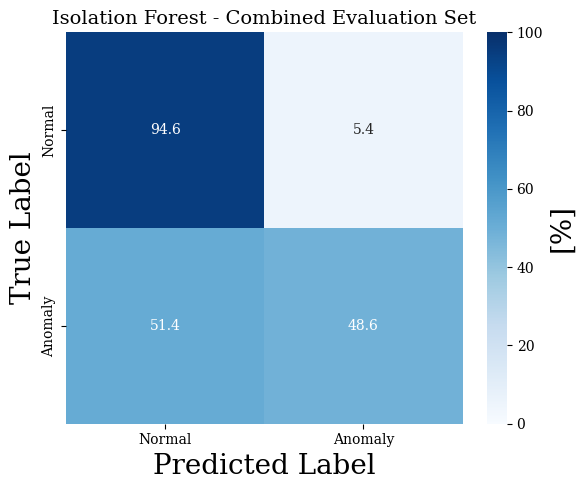

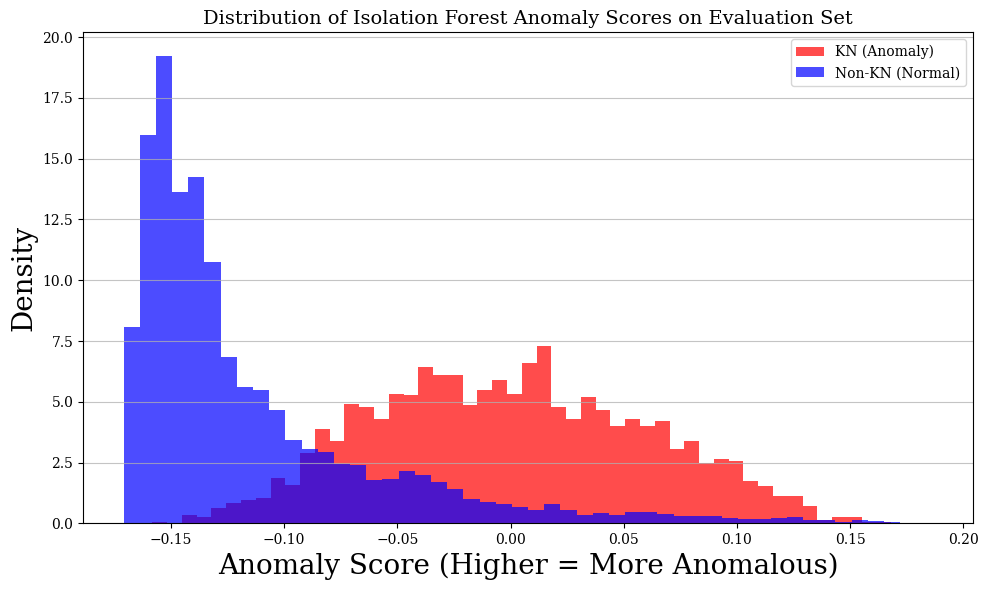

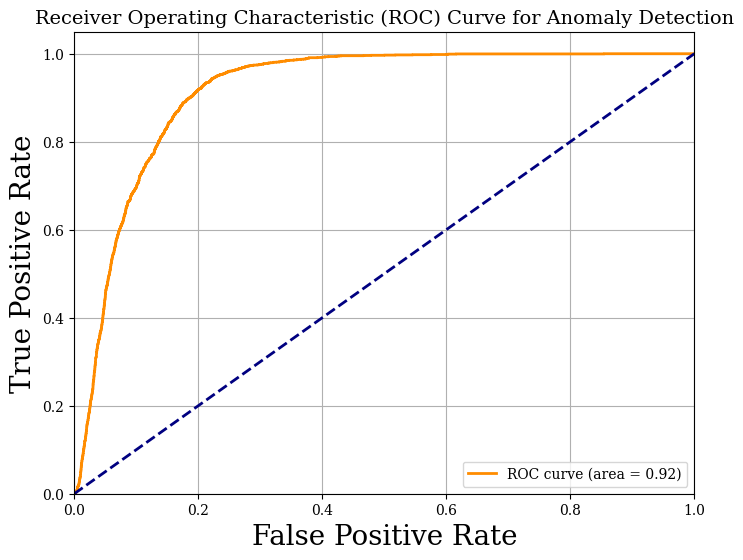


Example: Custom threshold set at 95th percentile of normal scores: 0.0064

[Evaluation with Custom Threshold (0.0064)]
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.94     14978
     Anomaly       0.57      0.45      0.50      2209

    accuracy                           0.89     17187
   macro avg       0.75      0.70      0.72     17187
weighted avg       0.88      0.89      0.88     17187



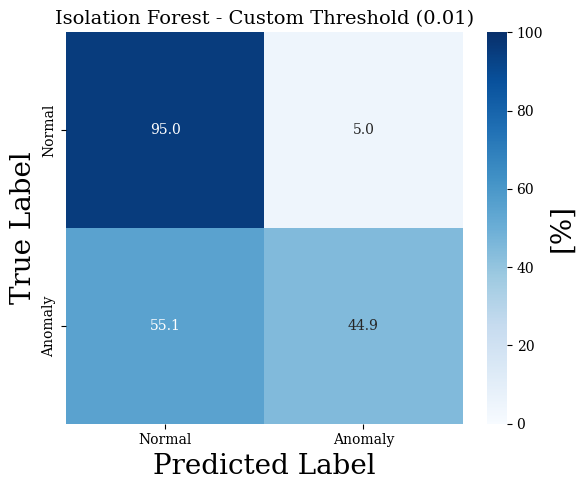

In [29]:

# ---------------------------------------------------------
# 3. Evaluate the Model
# ---------------------------------------------------------
print("\n[Evaluation on Training Set (non-KN)]")
# predict: normal=1, anomaly=-1
y_pred_train_raw = model.predict(X_train)
# Convert: -1 -> 1 (anomaly), 1 -> 0 (normal)
y_pred_train_bin = (y_pred_train_raw == -1).astype(int)
# True labels for training set (should be all normal, i.e., 0)
y_train_binary_true = (y_train == "KN").astype(int) # This should be all zeros if X_train contains no KN

print(classification_report(y_train_binary_true, y_pred_train_bin, target_names=["Normal", "Anomaly"]))


print("\n[Evaluation on Combined Test Set (non-KN test + all KN)]")
# Get raw predictions (-1 for anomaly, 1 for normal)
y_pred_eval_raw = model.predict(X_eval)
# Convert to binary: -1 -> 1 (anomaly), 1 -> 0 (normal)
y_pred_eval_bin = (y_pred_eval_raw == -1).astype(int)

# Classification Report
print(classification_report(y_eval_binary_true, y_pred_eval_bin, target_names=["Normal", "Anomaly"]))

# ---------------------------------------------------------
# 4. Confusion Matrix Visualization
# ---------------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, title, savepath):
    conf_matrix = confusion_matrix(y_true, y_pred)
    # Calculate percentages for better readability
    conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(conf_matrix_percent, annot=True, fmt=".1f", cmap="Blues",
                     xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"],
                     vmin=0, vmax=100, cbar_kws={'label': '[%]'})
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(savepath)
    plt.show() # Display the plot after saving

plot_confusion_matrix(y_eval_binary_true, y_pred_eval_bin,
                      title="Isolation Forest - Combined Evaluation Set",
                      savepath=f"{path_save}/confusion_matrix_iforest_combined_eval.png")

# ---------------------------------------------------------
# 5. Anomaly Score Distribution and ROC Curve
# ---------------------------------------------------------
# Calculate anomaly scores for the evaluation set
# Lower score indicates higher anomaly likelihood for IsolationForest
anomaly_scores_eval = -model.decision_function(X_eval) # Negate for typical 'higher score = more anomalous' interpretation
anomaly_scores_eng =  -model.decision_function(X_eng) # Negate for typical 'higher score = more anomalous' interpretation

# Plotting anomaly score distribution
plt.figure(figsize=(10, 6))
plt.hist(anomaly_scores_eval[y_eval_binary_true == 1], bins=50, alpha=0.7, label='KN (Anomaly)', histtype='stepfilled', density=True, color='red')
plt.hist(anomaly_scores_eval[y_eval_binary_true == 0], bins=50, alpha=0.7, label='Non-KN (Normal)', histtype='stepfilled', density=True, color='blue')
plt.xlabel("Anomaly Score (Higher = More Anomalous)")
plt.ylabel("Density")
plt.title("Distribution of Isolation Forest Anomaly Scores on Evaluation Set")
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig(f"{path_save}/anomaly_score_distribution.png")
plt.show()

# ROC Curve for anomaly detection
fpr, tpr, thresholds = roc_curve(y_eval_binary_true, anomaly_scores_eval)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Anomaly Detection')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(f"{path_save}/roc_curve_iforest.png")
plt.show()

# ---------------------------------------------------------
# 6. Evaluation with a Custom Threshold (Optional)
# ---------------------------------------------------------
# You can select a threshold based on the ROC curve or score distribution
# For example, to optimize for a specific precision/recall trade-off
optimal_threshold = np.percentile(anomaly_scores_eval[y_eval_binary_true == 0], 95) # Example: threshold where 5% of normal samples are classified as anomalies
print(f"\nExample: Custom threshold set at 95th percentile of normal scores: {optimal_threshold:.4f}")

# Apply the custom threshold to make binary predictions
y_pred_eval_bin_custom_thresh = (anomaly_scores_eval > optimal_threshold).astype(int)

print(f"\n[Evaluation with Custom Threshold ({optimal_threshold:.4f})]")
print(classification_report(y_eval_binary_true, y_pred_eval_bin_custom_thresh, target_names=["Normal", "Anomaly"]))

# Confusion Matrix for custom threshold
plot_confusion_matrix(y_eval_binary_true, y_pred_eval_bin_custom_thresh,
                      title=f"Isolation Forest - Custom Threshold ({optimal_threshold:.2f})",
                      savepath=f"{path_save}/confusion_matrix_iforest_custom_thresh.png")

## XGBoost

In [32]:
import pickle
import joblib

# trained_cat_pickle = os.path.join(MODEL, "Tune_CatBoost_40", "catboost_7DT.pkl")
trained_xgb_pickle = os.path.join(MODEL, "Tune_XGBoost_20", "xgboost_7DT.pkl")
# trained_lgb_pickle = os.path.join(MODEL, "Tune_LightGBM_40", "lightgbm_7DT.pkl")

# model_cat = joblib.load(trained_cat_pickle)
model_xgb = joblib.load(trained_xgb_pickle)
# model_lgb = joblib.load(trained_lgb_pickle)

In [33]:
import xgboost as xgb

label_encoder = LabelEncoder()
y_eval_encoded = label_encoder.fit_transform(y_eval_labels)

test_data_xgb = xgb.DMatrix(X_eval, label=y_eval_encoded)

# prob_cat = model_cat.predict_proba(test_data_cat)
prob_xgb = model_xgb.predict(test_data_xgb)
# prob_lgb = model_lgb.predict_proba(X_test)

# print(prob_xgb.shape)
max_prob_array = np.max(prob_xgb, axis=1)

In [34]:
y_eng_encoded = label_encoder.fit_transform(y_eng)
eng_data_xgb = xgb.DMatrix(X_eng, label=y_eng_encoded)

prob_eng_xgb = model_xgb.predict(eng_data_xgb)

max_prob_eng_array = np.max(prob_eng_xgb, axis=1)


# iForest + XGBoost

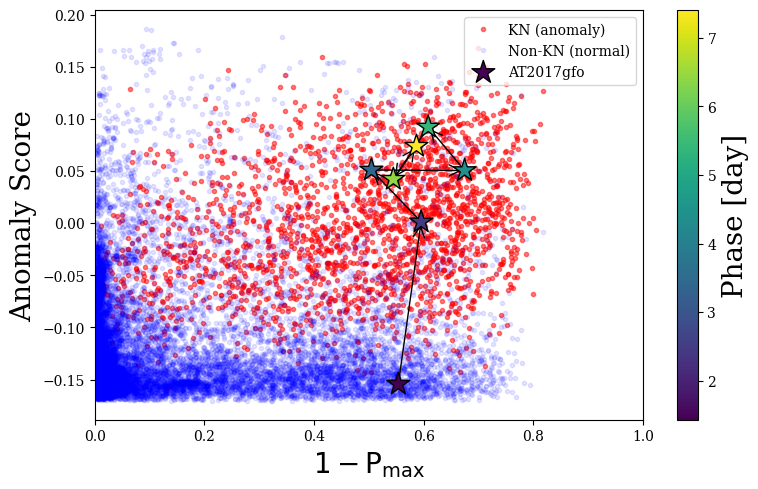

In [35]:
fig = plt.figure(figsize=(8, 5))

plt.plot(1-max_prob_array[y_eval_binary_true == 1], anomaly_scores_eval[y_eval_binary_true == 1], 'r.', alpha=0.5, label='KN (anomaly)')
plt.plot(1-max_prob_array[y_eval_binary_true == 0], anomaly_scores_eval[y_eval_binary_true == 0], 'b.', alpha=0.1, label='Non-KN (normal)')

plt.scatter(1-max_prob_eng_array, anomaly_scores_eng, c=phases, marker='*', s=300, ec='k', label='AT2017gfo', zorder=999)
cbar = plt.colorbar()
cbar.set_label("Phase [day]")
#
# 1. Phase 기준 정렬
sorted_idx = np.argsort(phases)
x_eng_sorted = 1 - max_prob_eng_array[sorted_idx]
y_eng_sorted = anomaly_scores_eng[sorted_idx]
phases_sorted = phases[sorted_idx]

# 2. 선으로 연결 (투명하게 그려도 좋음)
# plt.plot(x_eng_sorted, y_eng_sorted, '-', color='gray', lw=1.5, alpha=0.7, zorder=998)

# 3. 화살표 추가: 여러 개 or 하나만
for i in range(len(x_eng_sorted) - 1):
    plt.annotate(
        '',  # 텍스트 없음
        xy=(x_eng_sorted[i+1], y_eng_sorted[i+1]),
        xytext=(x_eng_sorted[i], y_eng_sorted[i]),
        arrowprops=dict(arrowstyle='->', color='k', lw=1),
        size=20,
        zorder=998,
    )

#
plt.xlabel(r"$\rm 1-P_{max}$")
plt.ylabel("Anomaly Score")
plt.xlim(0.0, 1.0)
plt.legend(loc='upper right')
plt.tight_layout()

AGN = 0
Asteroid = 1
II = 2
Ia = 3
Ibc = 4
SLSN = 6
SV = 7
TDE = 8


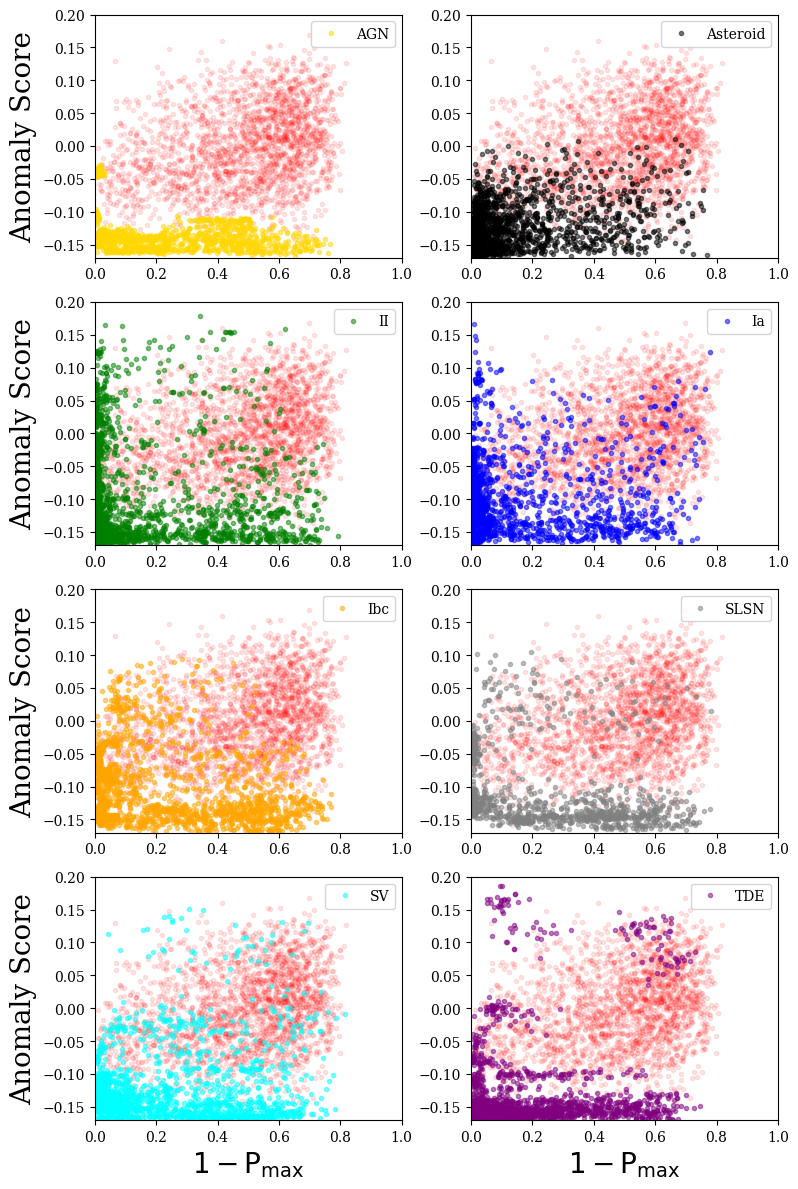

In [36]:
# label 별로 색상 지정 (원하는 label만 정의해도 됨)
label_colors = {
    "AGN": "gold",
    "Ia": "blue",
    "II": "green",
    "Ibc": "orange",
    "TDE": "purple",
    "SV": "cyan",
    "Asteroid": "k",
    "SLSN": "gray"
}



# plt.plot(1-max_prob_array[y_eval_binary_true == 0], anomaly_scores_eval[y_eval_binary_true == 0], 'b.', alpha=0.1, label='Non-KN (normal)')

fig = plt.figure(figsize=(8, 12))

for ii, (val, label) in enumerate(zip(np.unique(y_eval_encoded[y_eval_labels!="KN"]), np.unique(y_eval_labels[y_eval_labels!="KN"]))):
    plt.subplot(4, 2, ii+1)
    plt.plot(1-max_prob_array[y_eval_binary_true == 1], anomaly_scores_eval[y_eval_binary_true == 1], 'r.', alpha=0.1,)# label='KN (anomaly)')
    if label != "KN":
        print(f"{label} = {val}")
        color = label_colors[label]
        plt.plot(1-max_prob_array[y_eval_encoded == val], anomaly_scores_eval[y_eval_encoded == val], '.', c=color, alpha=0.5, label=f'{label}')
        #
        if ii in [6, 7]:
            plt.xlabel(r"$\rm 1-P_{max}$")
        if ii in [0, 2, 4, 6]:
            plt.ylabel("Anomaly Score")
        plt.xlim(0.0, 1.0)
        plt.ylim(-0.17, 0.20)
        plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

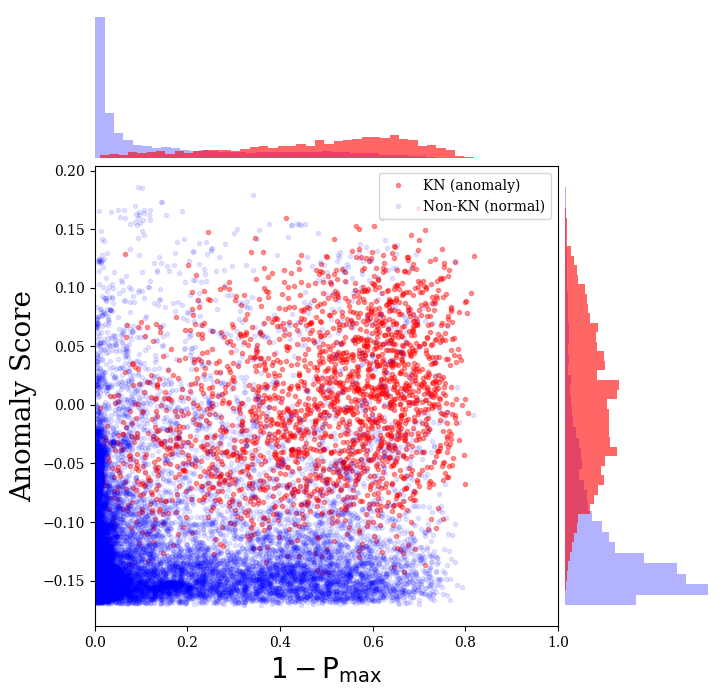

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 정의 (예시 변수 이름 그대로 사용)
x_kn = 1 - max_prob_array[y_eval_binary_true == 1]
y_kn = anomaly_scores_eval[y_eval_binary_true == 1]
x_nonn = 1 - max_prob_array[y_eval_binary_true == 0]
y_nonn = anomaly_scores_eval[y_eval_binary_true == 0]

# Figure와 그리드 정의
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(4, 4, hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1: , :-1])     # 중앙 scatter
ax_xhist = fig.add_subplot(gs[0, :-1], sharex=ax_main)  # 상단 histogram
ax_yhist = fig.add_subplot(gs[1:, -1], sharey=ax_main)  # 우측 histogram

# Scatter plot (중앙)
ax_main.plot(x_kn, y_kn, 'r.', alpha=0.4, label='KN (anomaly)')
ax_main.plot(x_nonn, y_nonn, 'b.', alpha=0.1, label='Non-KN (normal)')
ax_main.set_xlabel(r"$\rm 1-P_{max}$")
ax_main.set_ylabel("Anomaly Score")
ax_main.set_xlim(0.0, 1.0)
ax_main.legend(loc='upper right')

# Histogram (상단)
ax_xhist.hist(x_nonn, bins=40, color='blue', alpha=0.3, label='Non-KN', density=True)
ax_xhist.hist(x_kn, bins=40, color='red', alpha=0.6, label='KN', density=True)
ax_xhist.axis('off')  # 눈금 제거

# Histogram (우측)
ax_yhist.hist(y_nonn, bins=40, color='blue', alpha=0.3, orientation='horizontal', density=True)
ax_yhist.hist(y_kn, bins=40, color='red', alpha=0.6, orientation='horizontal', density=True)
ax_yhist.axis('off')

# # Histogram (상단)
# ax_xhist.hist([x_nonn, x_kn], bins=40, stacked=True, color=['blue', 'red'], alpha=[0.3, 0.6])
# ax_xhist.axis('off')  # 눈금 제거

# # Histogram (우측)
# ax_yhist.hist([y_nonn, y_kn], bins=40, stacked=True, color=['blue', 'red'], alpha=[0.3, 0.6], orientation='horizontal')
# ax_yhist.axis('off')  # 눈금 제거

plt.tight_layout()
plt.show()

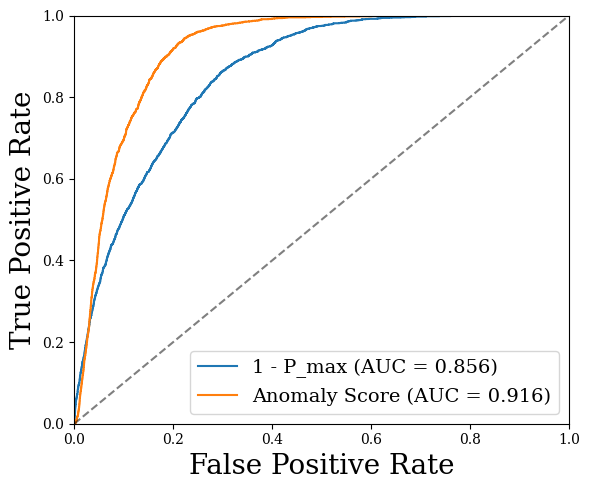

In [38]:
# 필요한 라이브러리 다시 import 및 재정의
from sklearn.metrics import roc_curve, auc

# 레이블: 0 = Non-KN, 1 = KN
x_all = np.concatenate([x_nonn, x_kn])
y_all = np.concatenate([y_nonn, y_kn])
label_all = np.concatenate([np.zeros_like(x_nonn), np.ones_like(x_kn)])

# ROC Curve for 1 - P_max
fpr_x, tpr_x, _ = roc_curve(label_all, x_all)
roc_auc_x = auc(fpr_x, tpr_x)

# ROC Curve for Anomaly Score
fpr_y, tpr_y, _ = roc_curve(label_all, y_all)
roc_auc_y = auc(fpr_y, tpr_y)

# Plotting
plt.figure(figsize=(6, 5))
plt.plot(fpr_x, tpr_x, label=f'1 - P_max (AUC = {roc_auc_x:.3f})',)# color='orange')
plt.plot(fpr_y, tpr_y, label=f'Anomaly Score (AUC = {roc_auc_y:.3f})',)# color='purple')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# plt.title("ROC Curve by Threshold on Single Features")
plt.legend(loc='lower right', fontsize=14)
# plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import roc_curve, auc, recall_score, f1_score
from mpl_toolkits.mplot3d import Axes3D # 3D 그래프를 위한 라이브러리

x_all = np.concatenate([x_nonn, x_kn]) # 1 - P_max 값들
y_all = np.concatenate([y_nonn, y_kn]) # Anomaly Score 값들
label_all = np.concatenate([np.zeros_like(x_nonn), np.ones_like(x_kn)]) # 실제 라벨

fpr_x, tpr_x, thresholds_x = roc_curve(label_all, x_all, pos_label=1)
roc_auc_x = auc(fpr_x, tpr_x)

fpr_y, tpr_y, thresholds_y = roc_curve(label_all, y_all, pos_label=1)
roc_auc_y = auc(fpr_y, tpr_y)

# --- 3D 그래프를 위한 임계값 그리드 생성 및 성능 계산 ---

# ROC curve에서 반환된 thresholds는 일반적으로 내림차순 정렬되어 있습니다.
# Recall/TPR을 계산하기 위해 실제 분류에 사용할 임계값 범위를 정의합니다.
# x_all (1-Pmax)에 대한 임계값 범위
thresholds_x_plot = np.linspace(x_all.min(), x_all.max(), 50)
# y_all (Anomaly Score)에 대한 임계값 범위
thresholds_y_plot = np.linspace(y_all.min(), y_all.max(), 50)

# 3D 그래프를 위한 그리드 생성
X_thresh, Y_thresh = np.meshgrid(thresholds_x_plot, thresholds_y_plot)

# Z 축 값 (예: Recall/TPR)을 저장할 배열
Z_recall = np.zeros_like(X_thresh)
Z_f1_score = np.zeros_like(X_thresh)

# 각 임계값 조합에 대해 Recall (TPR) 및 F1-Score 계산
for i in range(X_thresh.shape[0]):
    for j in range(X_thresh.shape[1]):
        thresh_x = X_thresh[i, j]
        thresh_y = Y_thresh[i, j]

        # 두 임계값을 모두 만족하는 경우를 KN (이상치)로 예측
        # 1-Pmax가 높고 (thresh_x보다 크고) Anomaly Score가 높은 경우 (thresh_y보다 큰 경우)를 이상치로 분류
        # 이 조건은 문제 정의에 따라 조정될 수 있습니다.
        # 예를 들어, 둘 중 하나만 만족해도 이상치로 볼 수도 있습니다.
        # 여기서는 "둘 다 높아야 이상치"라는 가정을 합니다.
        y_pred = ((x_all > thresh_x) & (y_all > thresh_y)).astype(int)

        # Recall (True Positive Rate) 계산
        # pos_label=1 (KN 클래스)에 대한 Recall
        Z_recall[i, j] = recall_score(label_all, y_pred, pos_label=1, zero_division=0)
        # F1-Score 계산
        Z_f1_score[i, j] = f1_score(label_all, y_pred, pos_label=1, zero_division=0)



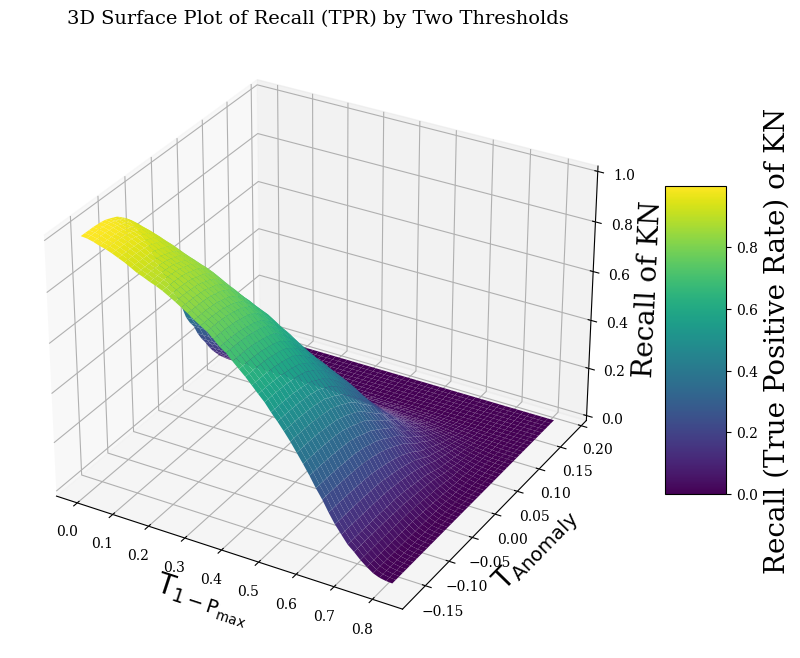

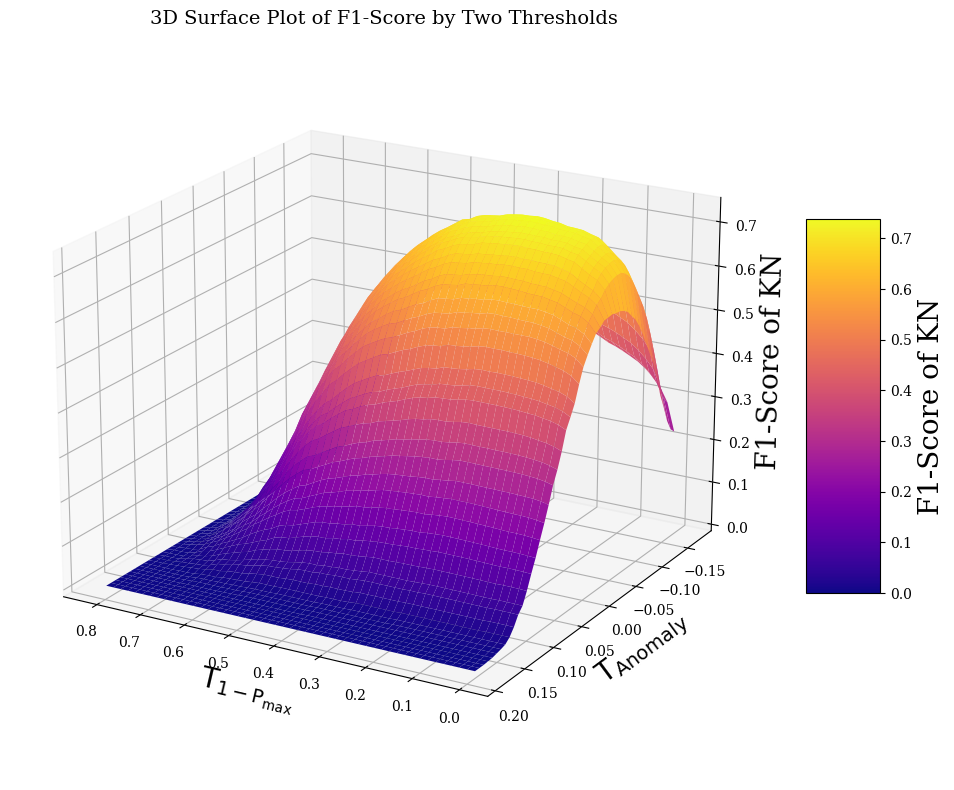

In [40]:
# --- 3D 그래프 시각화 ---

# 1. Recall (TPR)을 Z축으로 하는 3D 그래프
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(111, projection='3d')

surf1 = ax1.plot_surface(X_thresh, Y_thresh, Z_recall, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, shrink=0.5, aspect=5, label='Recall (True Positive Rate) of KN')

ax1.set_xlabel(r'$\rm T_{1-P_{max}}$')
ax1.set_ylabel(r'$\rm T_{Anomaly}$')
ax1.set_zlabel('Recall of KN')
ax1.set_title('3D Surface Plot of Recall (TPR) by Two Thresholds')

# 2. F1-Score를 Z축으로 하는 3D 그래프 (선택 사항, Recall과 F1-Score는 트레이드오프 관계이므로 함께 보는 것이 좋음)
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')

surf2 = ax2.plot_surface(X_thresh, Y_thresh, Z_f1_score, cmap='plasma', edgecolor='none')
fig2.colorbar(surf2, shrink=0.5, aspect=5, label='F1-Score of KN')

ax2.set_xlabel(r'$\rm T_{1-P_{max}}$')
ax2.set_ylabel(r'$\rm T_{Anomaly}$')
ax2.set_zlabel('F1-Score of KN')
ax2.set_title('3D Surface Plot of F1-Score by Two Thresholds')

ax2.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()

In [41]:
# Z_f1_score의 최대 위치 인덱스를 찾는다
max_idx = np.unravel_index(np.argmax(Z_f1_score), Z_f1_score.shape)

# 해당 위치의 threshold 값
best_T_pmax = X_thresh[max_idx]
best_T_anom = Y_thresh[max_idx]
max_f1 = Z_f1_score[max_idx]

print(best_T_pmax, best_T_anom, max_f1)

0.21749920991002297 -0.08340188121453651 0.7394957983193277


In [42]:
from sklearn.metrics import precision_recall_fscore_support

def find_threshold_max_recall(score_array, y_true, direction="greater", min_precision=0.0):

    thresholds = np.linspace(np.min(score_array), np.max(score_array), 500)
    best_recall, best_t = -1, None
    all_stats = []

    for t in thresholds:
        y_pred = score_array > t if direction == "greater" else score_array < t

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='binary', zero_division=0
        )
        all_stats.append((t, precision, recall, f1))

        if recall > best_recall and precision >= min_precision:
            best_recall = recall
            best_t = t

    return best_t, best_recall, all_stats

In [43]:
# KN을 놓치지 않기 위한 threshold
t1, recall1, stats1 = find_threshold_max_recall(1 - max_prob_array, y_eval_binary_true, direction="greater", min_precision=0.5)
t2, recall2, stats2 = find_threshold_max_recall(anomaly_scores_eval, y_eval_binary_true, direction="greater", min_precision=0.5)

print(f"[1 - P_max] Best threshold: {t1:.3f} (Recall = {recall1:.3f})")
print(f"[Anomaly Score] Best threshold: {t2:.3f} (Recall = {recall2:.3f})")

[1 - P_max] Best threshold: 0.594 (Recall = 0.343)
[Anomaly Score] Best threshold: -0.041 (Recall = 0.722)


In [44]:
mask = ((1 - max_prob_array) > t1) | (anomaly_scores_eval > t2)

# 평가
from sklearn.metrics import classification_report
print(classification_report(y_eval_binary_true, mask))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     14978
           1       0.44      0.78      0.56      2209

    accuracy                           0.84     17187
   macro avg       0.70      0.82      0.73     17187
weighted avg       0.90      0.84      0.86     17187



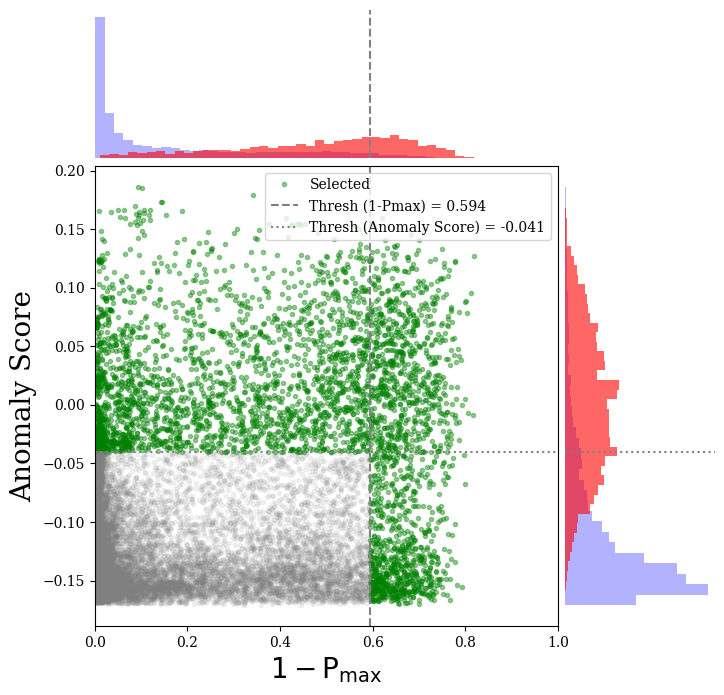

In [45]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(4, 4, hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1:, :-1])
ax_xhist = fig.add_subplot(gs[0, :-1], sharex=ax_main)
ax_yhist = fig.add_subplot(gs[1:, -1], sharey=ax_main)

# 중앙 Scatter plot
# ax_main.plot(x_kn, y_kn, 'r.', alpha=0.4, label='KN (anomaly)')
# ax_main.plot(x_nonn, y_nonn, 'b.', alpha=0.1, label='Non-KN (normal)')

# 조건 만족하는 마스크 포인트 강조
ax_main.plot(x_all[mask], y_all[mask], 'g.', alpha=0.4, label='Selected')
ax_main.plot(x_all[~mask], y_all[~mask], '.', c='grey', alpha=0.1,)# label='Selected as')

# Threshold 선 추가
ax_main.axvline(t1, color='gray', linestyle='--', label=f'Thresh (1-Pmax) = {t1:.3f}', alpha=1.0)
ax_main.axhline(t2, color='gray', linestyle=':', label=f'Thresh (Anomaly Score) = {t2:.3f}', alpha=1.0)

ax_main.set_xlabel(r"$\rm 1-P_{max}$")
ax_main.set_ylabel("Anomaly Score")
ax_main.set_xlim(0.0, 1.0)
ax_main.legend(loc='upper right')

# Histogram (상단)
ax_xhist.hist(x_nonn, bins=40, color='blue', alpha=0.3, density=True)
ax_xhist.hist(x_kn, bins=40, color='red', alpha=0.6, density=True)
ax_xhist.axvline(t1, color='gray', linestyle='--')
ax_xhist.axis('off')

# Histogram (우측)
ax_yhist.hist(y_nonn, bins=40, color='blue', alpha=0.3, density=True, orientation='horizontal')
ax_yhist.hist(y_kn, bins=40, color='red', alpha=0.6, density=True, orientation='horizontal')
ax_yhist.axhline(t2, color='gray', linestyle=':')
ax_yhist.axis('off')

plt.tight_layout()
plt.show()

최적의 a: 0.0586
최적의 b: -0.1838
최소 잘못 분류된 점의 수: 1235


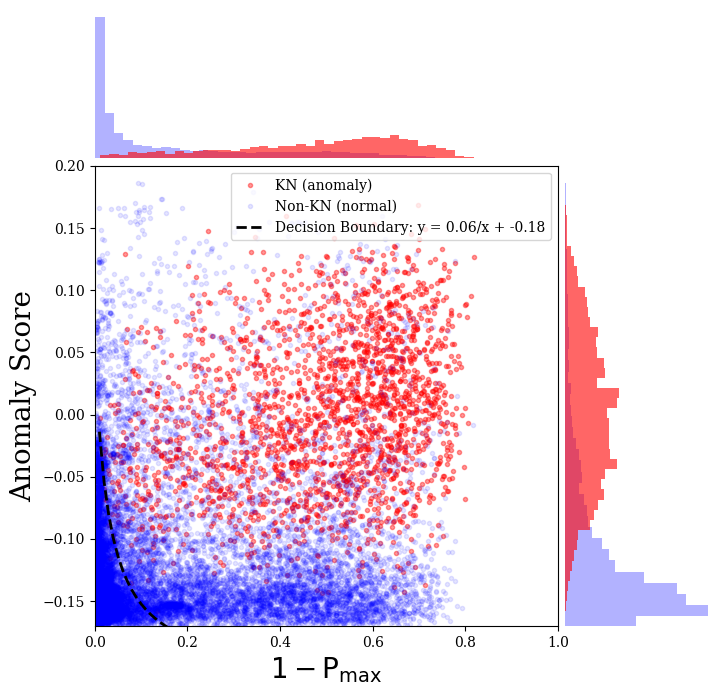

KN (빨간색) 잘못 분류된 비율: 0.2997
Non-KN (파란색) 잘못 분류된 비율: 0.0383


In [46]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(4, 4, hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1: , :-1])      # 중앙 scatter
ax_xhist = fig.add_subplot(gs[0, :-1], sharex=ax_main)  # 상단 histogram
ax_yhist = fig.add_subplot(gs[1:, -1], sharey=ax_main)  # 우측 histogram

# Scatter plot (중앙)
ax_main.plot(x_kn, y_kn, 'r.', alpha=0.4, label='KN (anomaly)')
ax_main.plot(x_nonn, y_nonn, 'b.', alpha=0.1, label='Non-KN (normal)')
ax_main.set_xlabel(r"$\rm 1-P_{max}$")
ax_main.set_ylabel("Anomaly Score")
ax_main.set_xlim(0.0, 1.0)
ax_main.legend(loc='upper right')

# Histogram (상단)
ax_xhist.hist(x_nonn, bins=40, color='blue', alpha=0.3, label='Non-KN', density=True)
ax_xhist.hist(x_kn, bins=40, color='red', alpha=0.6, label='KN', density=True)
ax_xhist.axis('off')  # 눈금 제거

# Histogram (우측)
ax_yhist.hist(y_nonn, bins=40, color='blue', alpha=0.3, orientation='horizontal', density=True)
ax_yhist.hist(y_kn, bins=40, color='red', alpha=0.6, orientation='horizontal', density=True)
ax_yhist.axis('off')

# --- a/x + b 함수를 통한 분리 최적화 ---

# 그리드 탐색을 위한 a, b 값 범위 설정
# 이미지에서 대략적인 경향을 보고 범위를 설정합니다.
# a는 음수 값일 가능성이 높고 (x가 커질수록 y는 작아지는 경향)
# b는 y 절편과 유사한 역할을 합니다.
a_values = np.linspace(-0.2, 0.2, 100)  # a 값의 범위 (예시)
b_values = np.linspace(-0.2, 0.2, 100)  # b 값의 범위 (예시)

best_a = None
best_b = None
min_misclassified = float('inf') # 잘못 분류된 점의 최소 개수

for a in a_values:
    for b in b_values:
        misclassified_count = 0

        # KN (빨간색) 점에 대한 분류 확인: y > a/x + b 이여야 함
        # x가 0에 가까울 때 발산하는 것을 피하기 위해 작은 epsilon 추가
        # 혹은 x_kn이 0인 경우를 처리
        kn_predictions = y_kn > (a / (x_kn + 1e-9) + b)
        misclassified_kn = np.sum(~kn_predictions) # KN인데 y <= a/x + b 인 경우

        # Non-KN (파란색) 점에 대한 분류 확인: y < a/x + b 이여야 함
        nonn_predictions = y_nonn < (a / (x_nonn + 1e-9) + b)
        misclassified_nonn = np.sum(~nonn_predictions) # Non-KN인데 y >= a/x + b 인 경우

        current_misclassified = misclassified_kn + misclassified_nonn

        if current_misclassified < min_misclassified:
            min_misclassified = current_misclassified
            best_a = a
            best_b = b

print(f"최적의 a: {best_a:.4f}")
print(f"최적의 b: {best_b:.4f}")
print(f"최소 잘못 분류된 점의 수: {min_misclassified}")

# 최적의 a, b 값을 사용하여 분리 경계선 그리기
x_line = np.linspace(0.01, 1.0, 100) # 0에서 발산 방지를 위해 0.01부터 시작
# y_line = best_a / (x_line+0.05) + (best_b-0.03)
y_line = 0.008/ (x_line+0.03) + (best_b-0.03)
ax_main.plot(x_line, y_line, 'k--', linewidth=2, label=f'Decision Boundary: y = {best_a:.2f}/x + {best_b:.2f}')
ax_main.legend(loc='upper right')

ax_main.set_ylim(-0.17, 0.2)

plt.show()

# 추가 분석: 각 클래스별 잘못 분류된 비율
total_kn = len(x_kn)
total_nonn = len(x_nonn)

kn_misclassified_rate = np.sum(y_kn <= (best_a / (x_kn + 1e-9) + best_b)) / total_kn
nonn_misclassified_rate = np.sum(y_nonn >= (best_a / (x_nonn + 1e-9) + best_b)) / total_nonn

print(f"KN (빨간색) 잘못 분류된 비율: {kn_misclassified_rate:.4f}")
print(f"Non-KN (파란색) 잘못 분류된 비율: {nonn_misclassified_rate:.4f}")

# Decide classification criteria

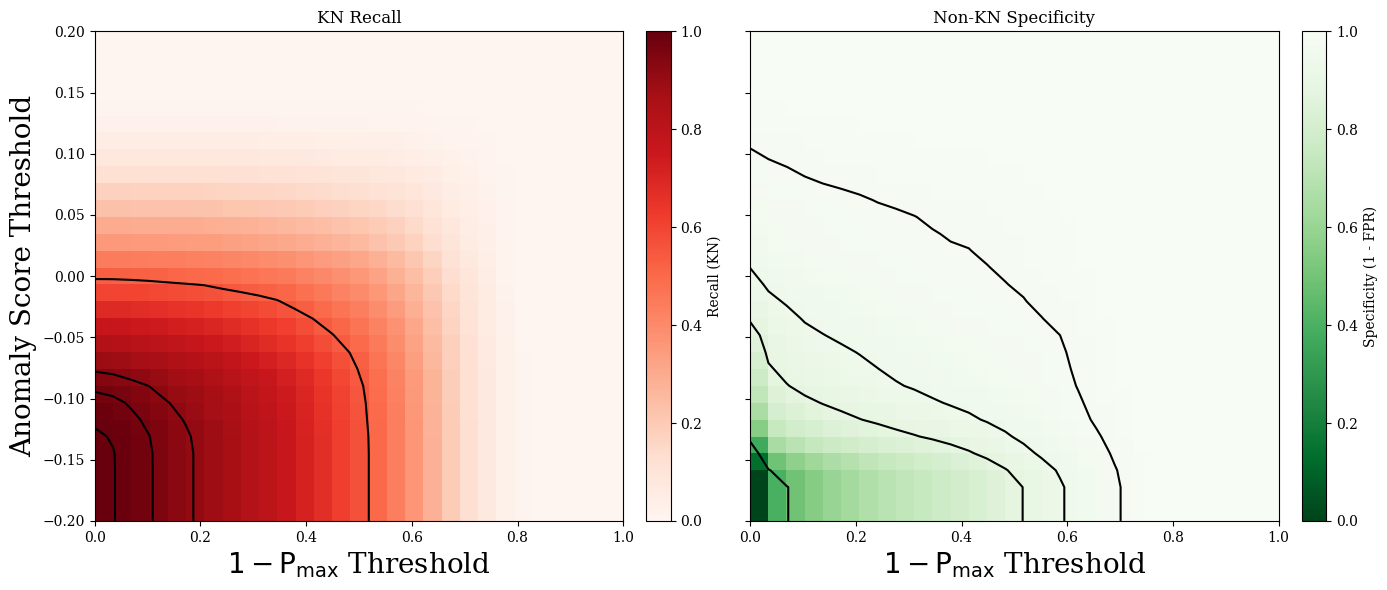

In [47]:
contour_levels = [0.5, 0.9, 0.95, 0.99]

# --- Threshold Grid 설정 ---
x_edges = np.linspace(0.0, 1.0, 30)
y_edges = np.linspace(-0.2, 0.2, 30)

recall_grid = np.zeros((len(x_edges)-1, len(y_edges)-1))
specificity_grid = np.zeros_like(recall_grid)

total_kn = len(x_kn)
total_nonn = len(x_nonn)

# 각 threshold pair에 대해 recall (KN), specificity (1 - FPR, Non-KN) 계산
for i, x_th in enumerate(x_edges[:-1]):
    for j, y_th in enumerate(y_edges[:-1]):
        # KN recall
        mask_kn = (x_kn > x_th) & (y_kn > y_th)
        TP = np.sum(mask_kn)
        FN = total_kn - TP
        recall_grid[i, j] = TP / (TP + FN + 1e-8)

        # Non-KN specificity
        mask_nonn = (x_nonn > x_th) & (y_nonn > y_th)
        FP = np.sum(mask_nonn)
        TN = total_nonn - FP
        specificity_grid[i, j] = TN / (TN + FP + 1e-8)

# --- 시각화 ---
fig, (ax_recall, ax_spec) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

# Recall (KN)
im1 = ax_recall.imshow(
    recall_grid.T,
    extent=extent,
    origin='lower',
    aspect='auto',
    cmap='Reds'
)
cbar1 = fig.colorbar(im1, ax=ax_recall, fraction=0.046, pad=0.04)
cbar1.set_label('Recall (KN)', fontsize=10)
ax_recall.contour(x_edges[:-1], y_edges[:-1], recall_grid.T, levels=contour_levels, colors='k', linestyles='-')
ax_recall.set_title("KN Recall", fontsize=12)
ax_recall.set_xlabel(r"$\rm 1 - P_{max}$ Threshold")
ax_recall.set_ylabel("Anomaly Score Threshold")

# ax_recall.scatter(x_th_opt, y_th_opt, color='black', marker='x', s=100, label='Best threshold')
# ax_recall.legend()


# Specificity (Non-KN)
im2 = ax_spec.imshow(
    specificity_grid.T,
    extent=extent,
    origin='lower',
    aspect='auto',
    cmap='Greens_r'
)
cbar2 = fig.colorbar(im2, ax=ax_spec, fraction=0.046, pad=0.04)
cbar2.set_label('Specificity (1 - FPR)', fontsize=10)
ax_spec.contour(x_edges[:-1], y_edges[:-1], specificity_grid.T, levels=contour_levels, colors='k', linestyles='-')
ax_spec.set_title("Non-KN Specificity", fontsize=12)
ax_spec.set_xlabel(r"$\rm 1 - P_{max}$ Threshold")

plt.tight_layout()
plt.show()


In [48]:
youden_j_grid = recall_grid + specificity_grid - 1

# 최대 위치
i_opt, j_opt = np.unravel_index(np.argmax(youden_j_grid), youden_j_grid.shape)
x_th_opt = x_edges[i_opt]
y_th_opt = y_edges[j_opt]

print(f"📌 최적 threshold (Youden's J 최대):")
print(f"    1 - P_max threshold = {x_th_opt:.3f}")
print(f"    Anomaly Score threshold = {y_th_opt:.3f}")
print(f"    Recall = {recall_grid[i_opt, j_opt]:.4f}")
print(f"    Specificity = {specificity_grid[i_opt, j_opt]:.4f}")


📌 최적 threshold (Youden's J 최대):
    1 - P_max threshold = 0.069
    Anomaly Score threshold = -0.103
    Recall = 0.9443
    Specificity = 0.8734


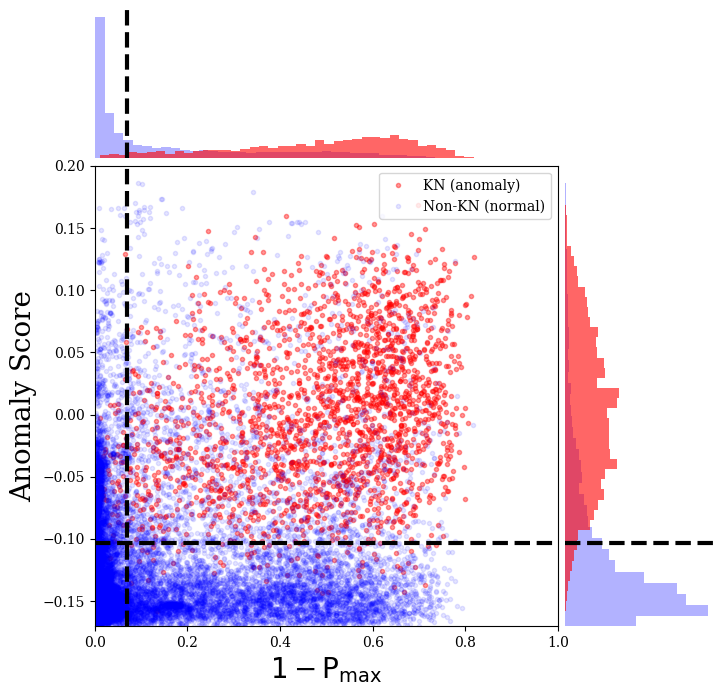

KN (빨간색) 잘못 분류된 비율: 0.2997
Non-KN (파란색) 잘못 분류된 비율: 0.0383


In [49]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(4, 4, hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1: , :-1])      # 중앙 scatter
ax_xhist = fig.add_subplot(gs[0, :-1], sharex=ax_main)  # 상단 histogram
ax_yhist = fig.add_subplot(gs[1:, -1], sharey=ax_main)  # 우측 histogram

# Scatter plot (중앙)
ax_main.plot(x_kn, y_kn, 'r.', alpha=0.4, label='KN (anomaly)')
ax_main.plot(x_nonn, y_nonn, 'b.', alpha=0.1, label='Non-KN (normal)')
ax_main.set_xlabel(r"$\rm 1-P_{max}$")
ax_main.set_ylabel("Anomaly Score")
ax_main.set_xlim(0.0, 1.0)
ax_main.legend(loc='upper right')

# Histogram (상단)
ax_xhist.hist(x_nonn, bins=40, color='blue', alpha=0.3, label='Non-KN', density=True)
ax_xhist.hist(x_kn, bins=40, color='red', alpha=0.6, label='KN', density=True)
ax_xhist.axis('off')  # 눈금 제거

# Histogram (우측)
ax_yhist.hist(y_nonn, bins=40, color='blue', alpha=0.3, orientation='horizontal', density=True)
ax_yhist.hist(y_kn, bins=40, color='red', alpha=0.6, orientation='horizontal', density=True)
ax_yhist.axis('off')

ax_main.axvline(x=x_th_opt, ls='--', lw=3, c='k')
ax_main.axhline(y=y_th_opt, ls='--', lw=3, c='k')

ax_xhist.axvline(x=x_th_opt, ls='--', lw=3, c='k')
ax_yhist.axhline(y=y_th_opt, ls='--', lw=3, c='k')

ax_main.legend(loc='upper right')

ax_main.set_ylim(-0.17, 0.2)

plt.show()

# 추가 분석: 각 클래스별 잘못 분류된 비율
total_kn = len(x_kn)
total_nonn = len(x_nonn)

kn_misclassified_rate = np.sum(y_kn <= (best_a / (x_kn + 1e-9) + best_b)) / total_kn
nonn_misclassified_rate = np.sum(y_nonn >= (best_a / (x_nonn + 1e-9) + best_b)) / total_nonn

print(f"KN (빨간색) 잘못 분류된 비율: {kn_misclassified_rate:.4f}")
print(f"Non-KN (파란색) 잘못 분류된 비율: {nonn_misclassified_rate:.4f}")

In [50]:
# 제약조건: specificity ≥ 0.95
spec_mask = specificity_grid >= 0.95

# 조건 만족하는 grid 중 recall 최대
masked_recall = np.where(spec_mask, recall_grid, -np.inf)
i_opt, j_opt = np.unravel_index(np.argmax(masked_recall), masked_recall.shape)

x_th_opt = x_edges[i_opt]
y_th_opt = y_edges[j_opt]

print(f"📌 Precision 조건하 Recall 최대:")
print(f"    1 - P_max threshold = {x_th_opt:.3f}")
print(f"    Anomaly Score threshold = {y_th_opt:.3f}")
print(f"    Recall = {recall_grid[i_opt, j_opt]:.4f}")
print(f"    Specificity = {specificity_grid[i_opt, j_opt]:.4f}")


📌 Precision 조건하 Recall 최대:
    1 - P_max threshold = 0.310
    Anomaly Score threshold = -0.090
    Recall = 0.7551
    Specificity = 0.9525


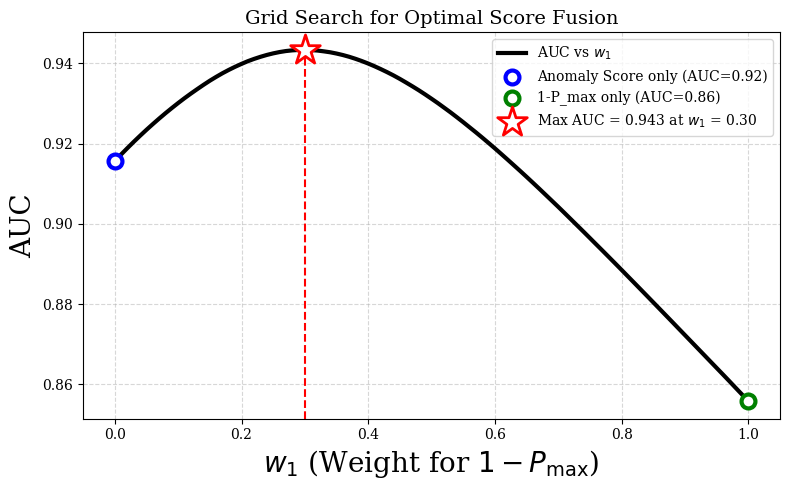

In [51]:
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# --- 1. 데이터 준비 ---
x_all = np.concatenate([x_kn, x_nonn])         # 1 - P_max
y_all = np.concatenate([y_kn, y_nonn])         # Anomaly Score
labels = np.concatenate([np.ones_like(x_kn), np.zeros_like(x_nonn)])

# --- 2. 정규화 ---
x_norm = (x_all - np.min(x_all)) / (np.max(x_all) - np.min(x_all))
y_norm = (y_all - np.min(y_all)) / (np.max(y_all) - np.min(y_all))

# --- 3. Grid Search ---
w1_grid = np.linspace(0, 1, 101)
auc_list = []

best_auc = 0
best_w1 = 0

for w1 in w1_grid:
    w2 = 1 - w1
    combined_score = w1 * x_norm + w2 * y_norm
    auc = roc_auc_score(labels, combined_score)
    auc_list.append(auc)

    if auc > best_auc:
        best_auc = auc
        best_w1 = w1

# --- 4. AUC of individual scores ---
roc_auc_x = roc_auc_score(labels, x_norm)  # 1 - P_max
roc_auc_y = roc_auc_score(labels, y_norm)  # Anomaly Score

# --- 5. 시각화 ---
plt.figure(figsize=(8, 5))
plt.plot(w1_grid, auc_list, color='black', label='AUC vs $w_1$', lw=3)

# 점 찍기: Anomaly Score only (w1 = 0)
plt.scatter(0, roc_auc_y, color='blue', fc='w', lw=3, s=100, zorder=5, label=f'Anomaly Score only (AUC={roc_auc_y:.2f})')
plt.scatter(1, roc_auc_x, color='green', fc='w', lw=3, s=100, zorder=5, label=f'1-P_max only (AUC={roc_auc_x:.2f})')

# 점 찍기: Best AUC (w1 = best_w1)
plt.scatter(best_w1, best_auc, color='red', fc='w', lw=2, s=500, zorder=5, marker='*', label=f'Max AUC = {best_auc:.3f} at $w_1$ = {best_w1:.2f}')

# 선은 제거하고 점으로만 강조
plt.axvline(best_w1, color='red', linestyle='--', alpha=1.0)

plt.xlabel(r"$w_1$ (Weight for $1 - P_{\mathrm{max}}$)")
plt.ylabel("AUC")
plt.title("Grid Search for Optimal Score Fusion")
plt.legend()
plt.grid('both', ls='--', alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()


In [52]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

def calculate_metrics(best_w1, threshold=0.5):
    
    # --- Combined Score with best weight ---
    w1 = best_w1
    w2 = 1 - best_w1
    combined_score = w1 * x_norm + w2 * y_norm
    
    # --- Threshold 설정 ---
    # 최적 threshold: ROC 또는 PR 곡선 기반으로 선택 가능하지만,
    # 여기서는 단순히 0.5 기준 또는 Youden's J 최대화로도 가능
    # 우선은 중간값 기준
    # threshold = 0.5
    
    # 이진 분류 결과
    y_pred = (combined_score >= threshold).astype(int)
    
    # --- Metric 계산 ---
    acc = accuracy_score(labels, y_pred)
    prec = precision_score(labels, y_pred)
    rec = recall_score(labels, y_pred)
    f1 = f1_score(labels, y_pred)
    
    tn, fp, fn, tp = confusion_matrix(labels, y_pred).ravel()
    spec = tn / (tn + fp)
    auc = roc_auc_score(labels, combined_score)
    
    # --- 결과 출력 ---
    print(f"📊 Metrics @ w1 = {w1:.2f}, threshold = {threshold:.2f}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  Precision    : {prec:.4f}")
    print(f"  Recall (TPR) : {rec:.4f}")
    print(f"  Specificity  : {spec:.4f}")
    print(f"  F1-score     : {f1:.4f}")
    print(f"  AUC (ROC)    : {auc:.4f}")

    return (acc, prec, rec, spec, f1, auc)

calculate_metrics(best_w1, threshold=0.5)

📊 Metrics @ w1 = 0.30, threshold = 0.50
  Accuracy     : 0.9119
  Precision    : 0.7125
  Recall (TPR) : 0.5274
  Specificity  : 0.9686
  F1-score     : 0.6061
  AUC (ROC)    : 0.9434


(0.9119101646593355,
 0.7125382262996942,
 0.5273879583521955,
 0.9686206436106289,
 0.6061394380853277,
 0.9433851405178478)

In [53]:
from sklearn.metrics import precision_recall_curve

# min precision 조건
min_precision = 0.7

# precision, recall, threshold 곡선 계산
precisions, recalls, thresholds = precision_recall_curve(labels, combined_score)

# precision 조건 만족하는 구간만 필터
valid = precisions[:-1] >= min_precision

if np.any(valid):
    idx = np.argmax(recalls[:-1][valid])
    best_threshold = thresholds[valid][idx]
    print(f"\n🎯 Precision ≥ {min_precision:.2f}일 때 최대 Recall 조건 threshold:")
    calculate_metrics(best_w1, threshold=best_threshold)
else:
    print("❌ 주어진 조건을 만족하는 threshold가 없음.")



🎯 Precision ≥ 0.70일 때 최대 Recall 조건 threshold:
📊 Metrics @ w1 = 0.30, threshold = 0.90
  Accuracy     : 0.8715
  Precision    : 1.0000
  Recall (TPR) : 0.0005
  Specificity  : 1.0000
  F1-score     : 0.0009
  AUC (ROC)    : 0.9434


In [54]:
# f1 계산 직접 수행
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

# 최댓값 위치
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

print(f"\n🎯 F1-score 최대 조건 threshold:")
calculate_metrics(best_w1, threshold=best_f1_threshold)



🎯 F1-score 최대 조건 threshold:
📊 Metrics @ w1 = 0.30, threshold = 0.58
  Accuracy     : 0.9005
  Precision    : 0.7343
  Recall (TPR) : 0.3540
  Specificity  : 0.9811
  F1-score     : 0.4777
  AUC (ROC)    : 0.9434


(0.9005061965438994,
 0.7342723004694836,
 0.35400633770937073,
 0.9811056215783148,
 0.4777031154551008,
 0.9433851405178478)